In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [8]:
df = pd.read_csv(r'D:\Projects\DataScience\College_Admission_Prediction\admission_predict.csv')
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [9]:
df = df.drop('Serial No.', axis=1)

In [11]:
df.isnull().sum()

GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

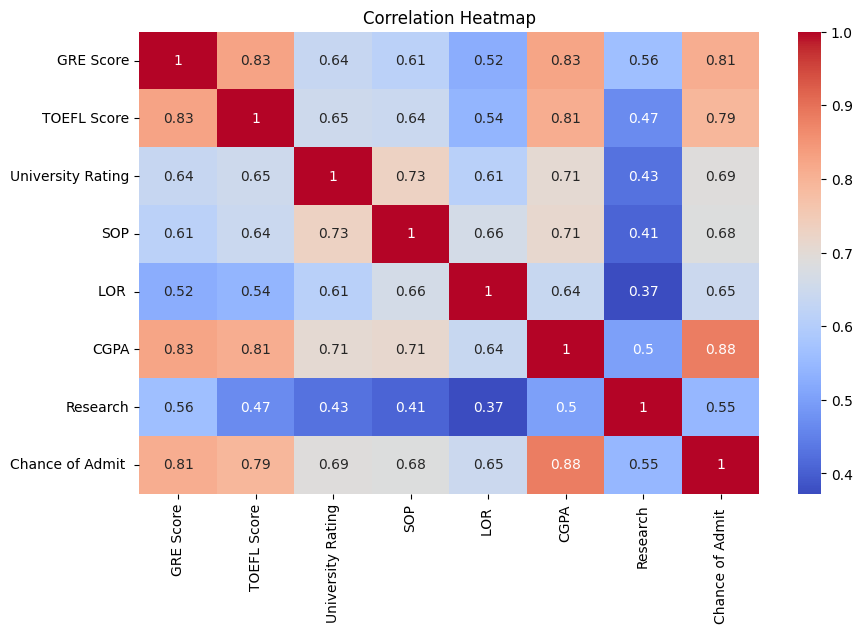

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

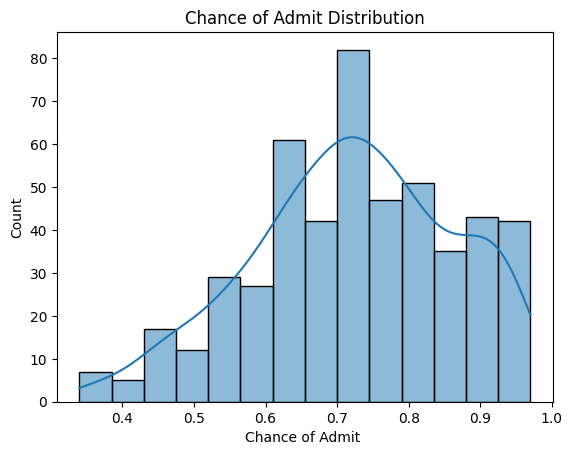

In [14]:
sns.histplot(df['Chance of Admit '], kde=True)
plt.title("Chance of Admit Distribution")
plt.show()

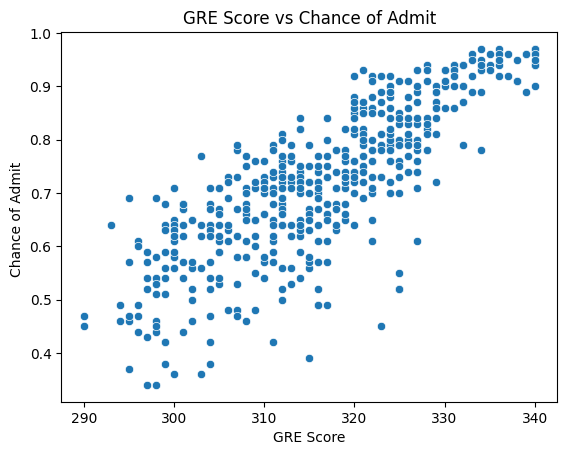

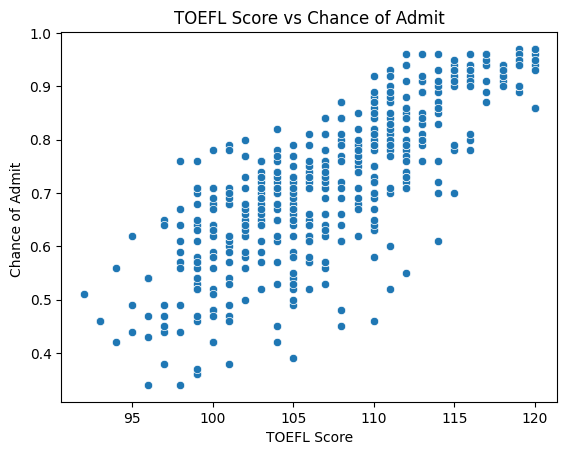

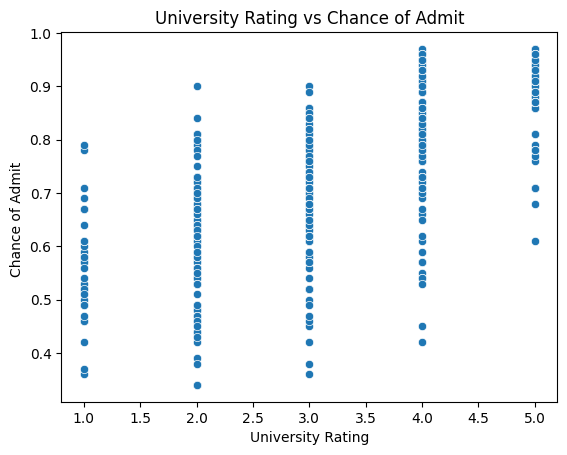

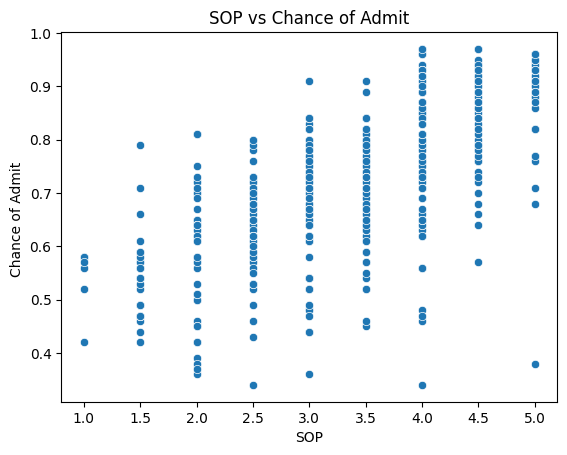

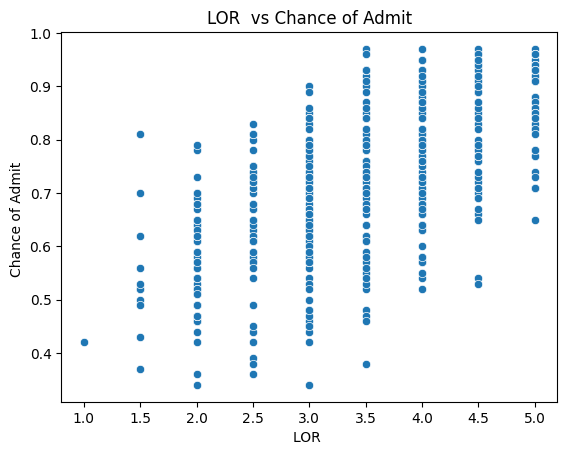

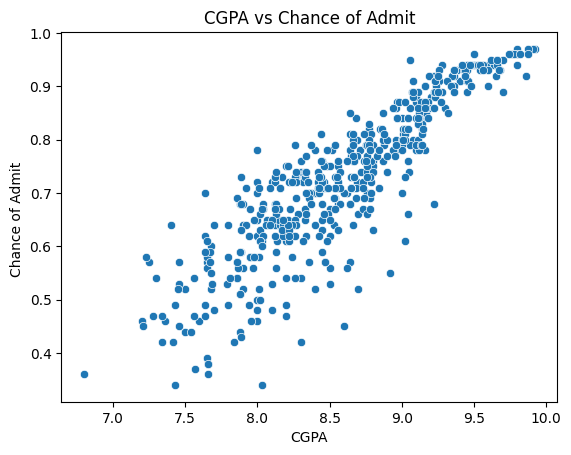

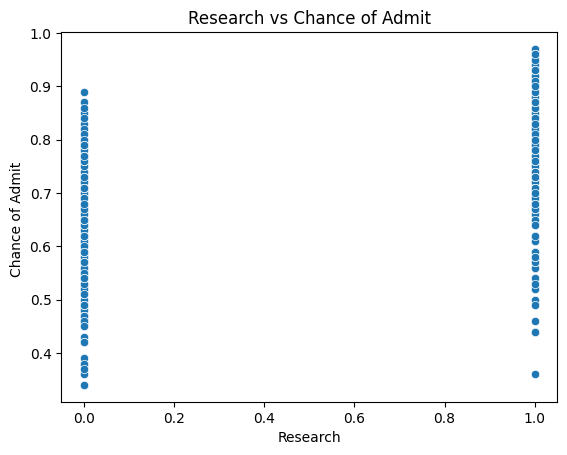

In [15]:
features = df.drop('Chance of Admit ', axis=1).columns

for col in features:
    plt.figure()
    sns.scatterplot(x=df[col], y=df['Chance of Admit '])
    plt.title(f"{col} vs Chance of Admit")
    plt.show()

In [16]:
X = df.drop('Chance of Admit ', axis=1)
y = df['Chance of Admit ']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "KNN": KNeighborsRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append([name, rmse, r2])

In [25]:
results_df = pd.DataFrame(results, columns=['Model', 'RMSE', 'R2 Score'])
results_df = results_df.sort_values(by='R2 Score', ascending=False)
print(results_df)

               Model      RMSE  R2 Score
0  Linear Regression  0.060866  0.818843
4      Random Forest  0.066387  0.784486
5                KNN  0.067043  0.780209
2                SVR  0.070212  0.758938
3      Decision Tree  0.092849  0.578435
1              Lasso  0.143521 -0.007248


In [26]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print("Best Model:", best_model_name)

Best Model: Linear Regression


In [27]:
def predict_admission(college_name, input_data):
    """
    input_data = [GRE, TOEFL, University Rating, SOP, LOR, CGPA, Research]
    """
    
    input_scaled = scaler.transform([input_data])
    prediction = best_model.predict(input_scaled)[0]
    
    print(f"Chance of getting into {college_name} is: {round(prediction*100, 2)}%")

In [34]:
predict_admission(
    "Yale",
    [320, 110, 4, 4.5, 4.5, 9.2, 1]
)

Chance of getting into Yale is: 84.24%


c:\Users\ishit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
